# Data Download and Cleaning

## Appliance Energy Forecasting

This notebook retrieves and prepares the Appliances Energy Prediction dataset for time-series forecasting.

The main objectives are to:

- load the original dataset;
- inspect the dataset structure;
- parse the timestamp;
- check missing values and duplicate observations;
- verify the temporal sampling frequency;
- resample the original 10-minute observations to hourly values;
- save the processed hourly dataset for subsequent analysis.

The target variable is `Appliances`, representing household appliance energy use.

The processed hourly dataset will later be used for benchmark forecasting, SARIMAX modelling, feature-based machine learning, and time-series foundation modelling.

In [2]:
# Import libraries

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [3]:
# Define project paths

from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"

OUTPUT_DIR = PROJECT_ROOT / "outputs"
FIGURE_DIR = OUTPUT_DIR / "figures"

for directory in [
    RAW_DIR,
    PROCESSED_DIR,
    FIGURE_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Raw data directory:", RAW_DIR)
print("Processed data directory:", PROCESSED_DIR)

Project root: C:\Users\LOJANA-UOH\OneDrive - University of Hertfordshire\DAwAI\Assignment-02\Appliance-Energy-Forecasting
Raw data directory: C:\Users\LOJANA-UOH\OneDrive - University of Hertfordshire\DAwAI\Assignment-02\Appliance-Energy-Forecasting\data\raw
Processed data directory: C:\Users\LOJANA-UOH\OneDrive - University of Hertfordshire\DAwAI\Assignment-02\Appliance-Energy-Forecasting\data\processed


## Dataset Retrieval

The analysis uses the publicly available **Appliances Energy Prediction** dataset.

The original dataset contains observations sampled at 10-minute intervals and includes:

- appliance energy consumption;
- lighting energy consumption;
- indoor temperature measurements;
- indoor relative humidity measurements;
- outdoor weather variables;
- timestamp information.

The modelling target is `Appliances`.

In [4]:
# Download the dataset

DATA_URL = (
    "https://archive.ics.uci.edu/ml/"
    "machine-learning-databases/00374/"
    "energydata_complete.csv"
)

RAW_FILE = RAW_DIR / "energydata_complete.csv"

if not RAW_FILE.exists():
    print("Downloading dataset...")
    data = pd.read_csv(DATA_URL)
    data.to_csv(RAW_FILE, index=False)
    print("Dataset downloaded and saved.")
else:
    print("Dataset already exists locally.")
    data = pd.read_csv(RAW_FILE)

print("Dataset shape:", data.shape)

Dataset downloaded and saved.
Dataset shape: (19735, 29)


In [5]:
data.head()

,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,T5,RH_5,T6,RH_6,T7,RH_7,T8,RH_8,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,45.566667,17.166667,55.20,7.026667,84.256667,17.200000,41.626667,18.2,48.900000,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,45.992500,17.166667,55.20,6.833333,84.063333,17.200000,41.560000,18.2,48.863333,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,45.890000,17.166667,55.09,6.560000,83.156667,17.200000,41.433333,18.2,48.730000,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,45.723333,17.166667,55.09,6.433333,83.423333,17.133333,41.290000,18.1,48.590000,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,45.530000,17.200000,55.09,6.366667,84.893333,17.200000,41.230000,18.1,48.590000,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


In [6]:
print("Number of rows:", data.shape[0])
print("Number of columns:", data.shape[1])

print("\nColumn names:")
for column in data.columns:
    print(column)

Number of rows: 19735
Number of columns: 29

Column names:
date
Appliances
lights
T1
RH_1
T2
RH_2
T3
RH_3
T4
RH_4
T5
RH_5
T6
RH_6
T7
RH_7
T8
RH_8
T9
RH_9
T_out
Press_mm_hg
RH_out
Windspeed
Visibility
Tdewpoint
rv1
rv2


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19735 entries, 0 to 19734
Data columns (total 29 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         19735 non-null  object 
 1   Appliances   19735 non-null  int64  
 2   lights       19735 non-null  int64  
 3   T1           19735 non-null  float64
 4   RH_1         19735 non-null  float64
 5   T2           19735 non-null  float64
 6   RH_2         19735 non-null  float64
 7   T3           19735 non-null  float64
 8   RH_3         19735 non-null  float64
 9   T4           19735 non-null  float64
 10  RH_4         19735 non-null  float64
 11  T5           19735 non-null  float64
 12  RH_5         19735 non-null  float64
 13  T6           19735 non-null  float64
 14  RH_6         19735 non-null  float64
 15  T7           19735 non-null  float64
 16  RH_7         19735 non-null  float64
 17  T8           19735 non-null  float64
 18  RH_8         19735 non-null  float64
 19  T9  

## Timestamp Preparation

Time-series forecasting requires a correctly ordered temporal index.

The `date` variable is therefore converted to a Pandas datetime type, the observations are sorted chronologically, and the timestamp is used as the DataFrame index.

In [8]:
data["date"] = pd.to_datetime(
    data["date"],
    errors="coerce"
)

print("Missing timestamps after conversion:")
print(data["date"].isna().sum())

data = (
    data
    .sort_values("date")
    .set_index("date")
)

data.head()

Missing timestamps after conversion:
0


,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,T5,RH_5,T6,RH_6,T7,RH_7,T8,RH_8,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,45.566667,17.166667,55.20,7.026667,84.256667,17.200000,41.626667,18.2,48.900000,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,45.992500,17.166667,55.20,6.833333,84.063333,17.200000,41.560000,18.2,48.863333,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,45.890000,17.166667,55.09,6.560000,83.156667,17.200000,41.433333,18.2,48.730000,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,45.723333,17.166667,55.09,6.433333,83.423333,17.133333,41.290000,18.1,48.590000,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389
2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,45.530000,17.200000,55.09,6.366667,84.893333,17.200000,41.230000,18.1,48.590000,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


In [9]:
# Verify chronological ordering

print("Start timestamp:", data.index.min())
print("End timestamp:", data.index.max())

print("\nIs index monotonic increasing?")
print(data.index.is_monotonic_increasing)

Start timestamp: 2016-01-11 17:00:00
End timestamp: 2016-05-27 18:00:00

Is index monotonic increasing?
True


##  Data Quality Checks

Before resampling and modelling, the dataset is checked for:

- missing observations;
- duplicate timestamps;
- irregular temporal intervals;
- missing target values.

These checks are important because gaps or duplicated timestamps can distort time-series features, seasonal patterns, and forecasting evaluation.

In [10]:
# Missing values
missing_summary = (
    data
    .isna()
    .sum()
    .sort_values(ascending=False)
)

missing_summary = pd.DataFrame({
    "missing_count": missing_summary,
    "missing_percentage": (
        missing_summary / len(data) * 100
    )
})

missing_summary

,missing_count,missing_percentage
Appliances,0,0.0
lights,0,0.0
T1,0,0.0
RH_1,0,0.0
T2,0,0.0
RH_2,0,0.0
T3,0,0.0
RH_3,0,0.0
T4,0,0.0
RH_4,0,0.0


In [11]:
# Missing target values

target_missing = data["Appliances"].isna().sum()

print("Missing values in Appliances:", target_missing)

Missing values in Appliances: 0


In [12]:
# Duplicate timestamps

duplicate_timestamps = data.index.duplicated().sum()

print("Duplicate timestamps:", duplicate_timestamps)

Duplicate timestamps: 0


In [13]:
# Verify the original 10-minute frequency

time_differences = (
    data.index
    .to_series()
    .diff()
    .dropna()
)

time_differences.value_counts().head(10)

date
0 days 00:10:00    19734
Name: count, dtype: int64

In [14]:
# Frequency distribution

frequency_percentage = (
    time_differences
    .value_counts(normalize=True)
    .mul(100)
)

frequency_percentage.head(10)

date
0 days 00:10:00    100.0
Name: proportion, dtype: float64

In [16]:
# Numerical descriptive statistics

data.describe().T

,count,mean,std,min,25%,50%,75%,max
Appliances,19735.0,97.694958,102.524891,10.000000,50.000000,60.000000,100.000000,1080.000000
lights,19735.0,3.801875,7.935988,0.000000,0.000000,0.000000,0.000000,70.000000
T1,19735.0,21.686571,1.606066,16.790000,20.760000,21.600000,22.600000,26.260000
RH_1,19735.0,40.259739,3.979299,27.023333,37.333333,39.656667,43.066667,63.360000
T2,19735.0,20.341219,2.192974,16.100000,18.790000,20.000000,21.500000,29.856667
RH_2,19735.0,40.420420,4.069813,20.463333,37.900000,40.500000,43.260000,56.026667
T3,19735.0,22.267611,2.006111,17.200000,20.790000,22.100000,23.290000,29.236000
RH_3,19735.0,39.242500,3.254576,28.766667,36.900000,38.530000,41.760000,50.163333
T4,19735.0,20.855335,2.042884,15.100000,19.530000,20.666667,22.100000,26.200000
RH_4,19735.0,39.026904,4.341321,27.660000,35.530000,38.400000,42.156667,51.090000


In [17]:
# Target statistics

target_summary = data["Appliances"].describe()

target_summary

count    19735.000000
mean        97.694958
std        102.524891
min         10.000000
25%         50.000000
50%         60.000000
75%        100.000000
max       1080.000000
Name: Appliances, dtype: float64

##  Hourly Resampling

The original dataset is recorded every 10 minutes. To reduce computational complexity and align the forecasting task with a 24-step daily horizon, the observations are resampled to hourly frequency.

Hourly values are calculated using the arithmetic mean of the six 10-minute observations within each hour.

After resampling, one daily seasonal cycle corresponds to 24 observations and one weekly seasonal cycle corresponds to 168 observations.

In [19]:
# Hourly resampling

hourly_data = data.resample("h").mean()

print("Original shape:", data.shape)
print("Hourly shape:", hourly_data.shape)

hourly_data.head()

Original shape: (19735, 28)
Hourly shape: (3290, 28)


,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,T5,RH_5,T6,RH_6,T7,RH_7,T8,RH_8,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2016-01-11 17:00:00,55.000000,35.000000,19.890000,46.502778,19.200000,44.626528,19.790000,44.897778,18.932778,45.738750,17.166667,55.116667,6.586667,84.260000,17.177778,41.400000,18.150000,48.710556,17.016667,45.446667,6.308333,733.750000,92.000000,6.166667,53.416667,5.050000,26.823044,26.823044
2016-01-11 18:00:00,176.666667,51.666667,19.897778,45.879028,19.268889,44.438889,19.770000,44.863333,18.908333,46.066667,17.111111,54.977778,6.180000,87.204444,17.229583,42.046806,18.094444,48.597222,16.981667,45.290000,5.941667,734.266667,91.583333,5.416667,40.000000,4.658333,22.324206,22.324206
2016-01-11 19:00:00,173.333333,25.000000,20.495556,52.805556,19.925556,46.061667,20.052222,47.227361,18.969444,47.815556,17.136111,55.869861,5.857361,88.131389,17.850000,45.017778,18.156111,49.213333,16.902222,45.311389,6.000000,734.791667,89.750000,6.000000,40.000000,4.391667,33.734932,33.734932
2016-01-11 20:00:00,125.000000,35.000000,20.961111,48.453333,20.251111,45.632639,20.213889,47.268889,19.190833,49.227917,17.615556,74.027778,5.469444,86.933889,17.632222,42.920000,18.773333,50.195556,16.890000,45.118889,6.000000,735.283333,87.583333,6.000000,40.000000,4.016667,25.679642,25.679642
2016-01-11 21:00:00,103.333333,23.333333,21.311667,45.768333,20.587778,44.961111,20.373333,46.164444,19.425556,47.918889,18.427222,69.037778,5.578889,86.129444,17.863611,43.618333,19.153333,49.542222,16.890000,44.807778,5.833333,735.566667,87.416667,6.000000,40.000000,3.816667,18.826274,18.826274


In [20]:
# Check missing values after resampling

hourly_missing = hourly_data.isna().sum()

hourly_missing[hourly_missing > 0]

Series([], dtype: int64)

In [21]:
# Verify hourly frequency

hourly_differences = (
    hourly_data.index
    .to_series()
    .diff()
    .dropna()
)

hourly_differences.value_counts().head()


date
0 days 01:00:00    3289
Name: count, dtype: int64

## Initial Time-Series Inspection

An initial plot of hourly appliance energy use is used to examine temporal variation, potential seasonality, changes in variance, unusual peaks, and other structural characteristics before formal statistical analysis.

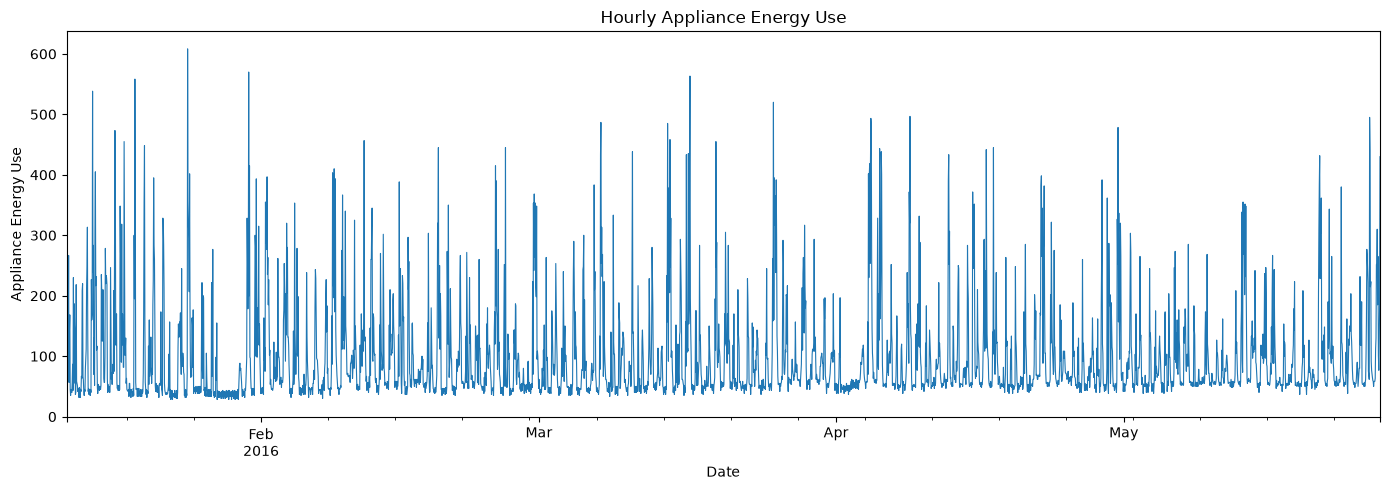

Figure saved to:
C:\Users\LOJANA-UOH\OneDrive - University of Hertfordshire\DAwAI\Assignment-02\Appliance-Energy-Forecasting\outputs\figures\01_hourly_appliance_energy_use.png


In [24]:
fig, ax = plt.subplots(figsize=(14, 5))

hourly_data["Appliances"].plot(
    ax=ax,
    linewidth=0.8
)

ax.set_title("Hourly Appliance Energy Use")
ax.set_xlabel("Date")
ax.set_ylabel("Appliance Energy Use")

fig.tight_layout()

# Save figure for the report
figure_path = FIGURE_DIR / "01_hourly_appliance_energy_use.png"

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved to:")
print(figure_path)

In [23]:
# Save the processed dataset

PROCESSED_FILE = (
    PROCESSED_DIR /
    "appliance_energy_hourly.csv"
)

hourly_data.to_csv(PROCESSED_FILE)

print("Processed dataset saved to:")
print(PROCESSED_FILE)

print("\nFinal hourly dataset shape:")
print(hourly_data.shape)

Processed dataset saved to:
C:\Users\LOJANA-UOH\OneDrive - University of Hertfordshire\DAwAI\Assignment-02\Appliance-Energy-Forecasting\data\processed\appliance_energy_hourly.csv

Final hourly dataset shape:
(3290, 28)
